Calculate the avg marks and prin t class fialed or passed is the avg is 50 or above

In [19]:
marks = [45, 60, 72, 38, 90]

total = 0

for i in range(len(marks) - 1):
    total += marks[i]

average = total / len(marks)

if average > 50:
    print("Class passed")
else:
    print("Class failed")

print("Average:", average)

Class failed
Average: 43.0


In [20]:
import pandas as pd

In [21]:
data = {
    "student_id": [101, 102, 103, 104, 105, 106],
    "attendance_percent": [92, 67, 81, 45, 74, 88],
    "assignment_score": [18, 12, 15, 8, 14, 19],
    "quiz_score": [72, 48, 65, 30, 55, 80],
    "lab_completed": [True, False, True, False, True, True]
}

df = pd.DataFrame(data)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True
5,106,88,19,80,True


In [22]:
df.shape

(6, 5)

In [23]:
df.head()

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed
0,101,92,18,72,True
1,102,67,12,48,False
2,103,81,15,65,True
3,104,45,8,30,False
4,105,74,14,55,True


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   student_id          6 non-null      int64
 1   attendance_percent  6 non-null      int64
 2   assignment_score    6 non-null      int64
 3   quiz_score          6 non-null      int64
 4   lab_completed       6 non-null      bool 
dtypes: bool(1), int64(4)
memory usage: 330.0 bytes


In [25]:
df.describe()

,student_id,attendance_percent,assignment_score,quiz_score
count,6.000000,6.000000,6.000000,6.000000
mean,103.500000,74.500000,14.333333,58.333333
std,1.870829,17.073371,4.033196,18.007406
min,101.000000,45.000000,8.000000,30.000000
25%,102.250000,68.750000,12.500000,49.750000
50%,103.500000,77.500000,14.500000,60.000000
75%,104.750000,86.250000,17.250000,70.250000
max,106.000000,92.000000,19.000000,80.000000


In [26]:
df['total_score'] = df['assignment_score'] + df['quiz_score']
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score
0,101,92,18,72,True,90
1,102,67,12,48,False,60
2,103,81,15,65,True,80
3,104,45,8,30,False,38
4,105,74,14,55,True,69
5,106,88,19,80,True,99


In [27]:
df['eligible'] = (
    (df['attendance_percent'] >= 75) &
    (df['total_score'] >= 70) &
    (df['lab_completed'])
)
df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
1,102,67,12,48,False,60,False
2,103,81,15,65,True,80,True
3,104,45,8,30,False,38,False
4,105,74,14,55,True,69,False
5,106,88,19,80,True,99,True


In [28]:
eligible_students = df[df["eligible"] == True]
eligible_students

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible
0,101,92,18,72,True,90,True
2,103,81,15,65,True,80,True
5,106,88,19,80,True,99,True


In [29]:
df['average_score'] = (
    df['assignment_score'] + df['quiz_score']
) / 2

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,average_score
0,101,92,18,72,True,90,True,45.0
1,102,67,12,48,False,60,False,30.0
2,103,81,15,65,True,80,True,40.0
3,104,45,8,30,False,38,False,19.0
4,105,74,14,55,True,69,False,34.5
5,106,88,19,80,True,99,True,49.5


In [30]:
df['attendance_category'] = df['attendance_percent'].apply(
    lambda x: 'Good' if x >= 75 else 'Poor'
)

df

,student_id,attendance_percent,assignment_score,quiz_score,lab_completed,total_score,eligible,average_score,attendance_category
0,101,92,18,72,True,90,True,45.0,Good
1,102,67,12,48,False,60,False,30.0,Poor
2,103,81,15,65,True,80,True,40.0,Good
3,104,45,8,30,False,38,False,19.0,Poor
4,105,74,14,55,True,69,False,34.5,Poor
5,106,88,19,80,True,99,True,49.5,Good


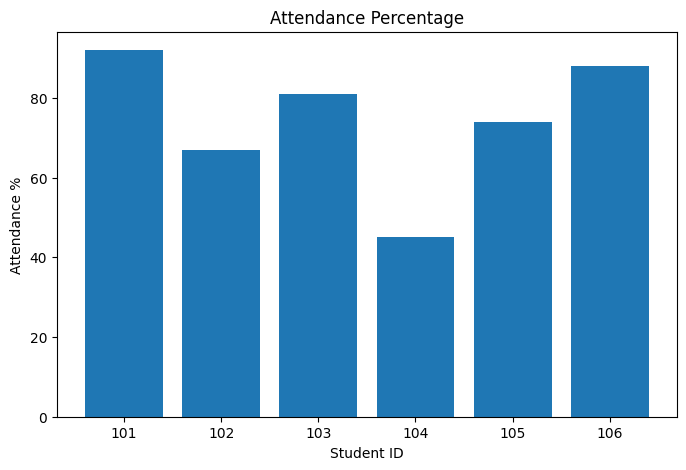

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    df['student_id'],
    df['attendance_percent']
)

plt.title("Attendance Percentage")
plt.xlabel("Student ID")
plt.ylabel("Attendance %")

plt.show()

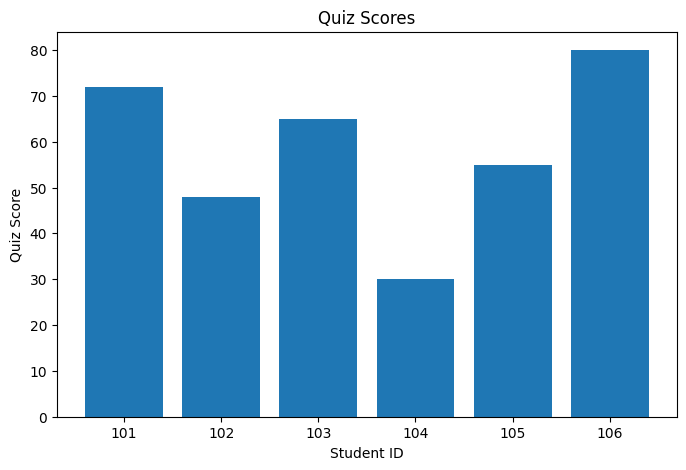

In [32]:
plt.figure(figsize=(8,5))

plt.bar(
    df['student_id'],
    df['quiz_score']
)

plt.title("Quiz Scores")
plt.xlabel("Student ID")
plt.ylabel("Quiz Score")

plt.show()

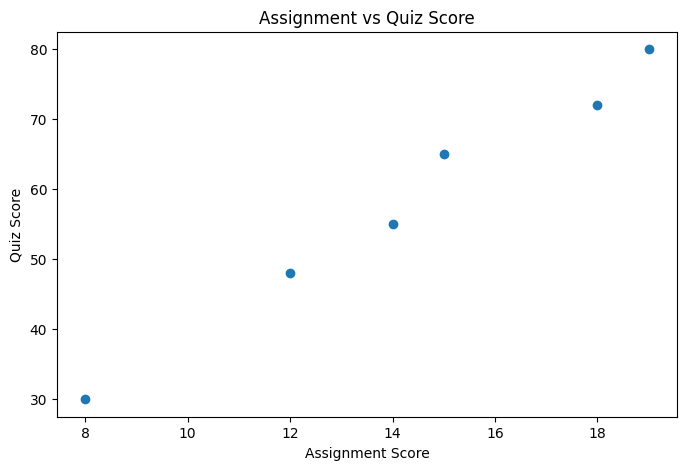

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(
    df['assignment_score'],
    df['quiz_score']
)

plt.title("Assignment vs Quiz Score")
plt.xlabel("Assignment Score")
plt.ylabel("Quiz Score")

plt.show()

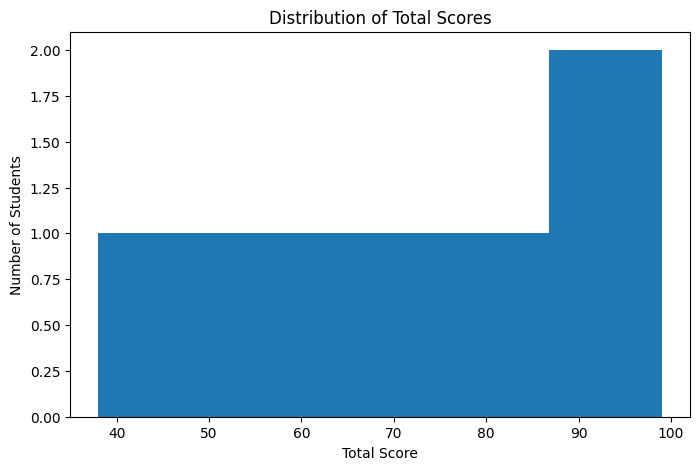

In [34]:
plt.figure(figsize=(8,5))

plt.hist(
    df['total_score'],
    bins=5
)

plt.title("Distribution of Total Scores")
plt.xlabel("Total Score")
plt.ylabel("Number of Students")

plt.show()

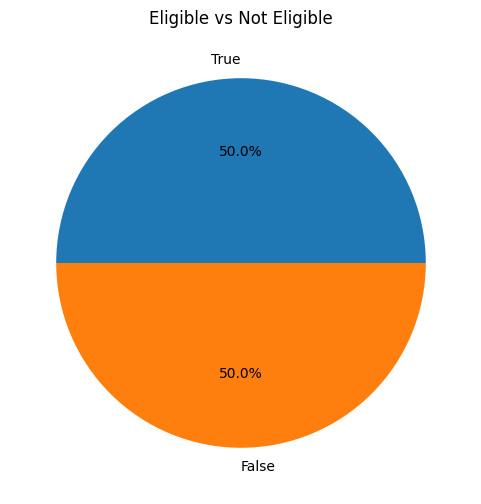

In [35]:
eligible_counts = df['eligible'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    eligible_counts,
    labels=eligible_counts.index,
    autopct='%1.1f%%'
)

plt.title("Eligible vs Not Eligible")

plt.show()